# Language Modelling 3

My notes for the following video by Andrej Karpathy:

- [_Building makemore Part 5: Building a WaveNet_](https://www.youtube.com/watch?v=t3YJ5hKiMQ0)

We will implement a simplified WaveNet model.

## Model

Recall that our previous model used three characters of context to predict the next character in the sequence. In the context of our input data of first names, this produced name-like sounding words, but obviously had some shortcomings. One proposed attempt at increasing the model's performance was to increase this context length. This gives a slight performance increase, but can be improved upon. Intuitively, there is a lot of local structure (e.g. letter pairs within a word) that is discarded in favour of the global structure of the full context.

Instead, it is possible to set up a neural network in which both local structure and global structure are both taken into account.

In [67]:
# DATA

import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import random
%matplotlib inline

# Import data and create mappings
words = open('names.txt', 'r').read().splitlines()
chars = sorted(list(set(''.join(words))))
stoi = {s: i+1 for i, s in enumerate(chars)}
stoi['.'] = 0
itos = {i: s for s, i in stoi.items()}
vocab_size = len(itos)

# Build dataset
block_size = 8
random.shuffle(words)

def build_dataset(words):
    X, Y = [], []
    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]

    X = torch.tensor(X)
    Y = torch.tensor(Y)
    return X, Y

n1 = int(0.8*len(words))
n2 = int(0.9*len(words))
Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

In [81]:
# MODEL

class Linear:
    def __init__(self, fan_in, fan_out, bias=True):
        self.weight = torch.randn((fan_in, fan_out)) / fan_in**0.5
        self.bias = torch.zeros(fan_out) if bias else None

    def __call__(self, x):
        self.out = x @ self.weight
        if self.bias is not None:
            self.out += self.bias
        return self.out

    def parameters(self):
        return [self.weight] + ([] if self.bias is None else [self.bias])

class BatchNorm1d:
    def __init__(self, dim, eps=1e-5, momentum=0.1):
        self.eps = eps
        self.momentum = momentum
        self.training = True
        self.gamma = torch.ones(dim)
        self.beta = torch.zeros(dim)
        self.running_mean = torch.zeros(dim)
        self.running_var = torch.ones(dim)

    def __call__(self, x):
        if self.training:
            if x.ndim == 2:
                dim = 0
            elif x.ndim == 3:
                dim = (0, 1)
            xmean = x.mean(dim, keepdim=True)
            xvar = x.var(dim, keepdim=True)
        else:
            xmean = self.running_mean
            xvar = self.running_var
        xhat = (x - xmean) / torch.sqrt(xvar + self.eps)
        self.out = self.gamma * xhat + self.beta
        if self.training:
            with torch.no_grad():
                self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
                self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar
        return self.out

    def parameters(self):
        return [self.gamma, self.beta]

class Tanh:
    def __call__(self, x):
        self.out = torch.tanh(x)
        return self.out
    def parameters(self):
        return []     

class Embedding:
    def __init__(self, num_embeddings, embedding_dim):
        self.weight = torch.randn((num_embeddings, embedding_dim))

    def __call__(self, IX):
        self.out = self.weight[IX]
        return self.out

    def parameters(self):
        return [self.weight]

class FlattenConsecutive:
    def __init__(self, n):
        self.n = n

    def __call__(self, x):
        B, T, C = x.shape
        x = x.view(B, T // self.n, C * self.n)
        if x.shape[1] == 1:
            x = x.squeeze(1)
        self.out = x
        return self.out

    def parameters(self):
        return []

class Sequential:
    def __init__(self, layers):
        self.layers = layers

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        self.out = x
        return self.out

    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]

n_embd = 24
n_hidden = 128

model = Sequential([
    Embedding(vocab_size, n_embd), 
    FlattenConsecutive(2), Linear(n_embd * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    FlattenConsecutive(2), Linear(n_hidden * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    FlattenConsecutive(2), Linear(n_hidden * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, vocab_size),
])

with torch.no_grad():
    model.layers[-1].weight *= 0.1

parameters = model.parameters()
print(sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad = True

76579


In [77]:
# OPTIMIZATION

max_steps = 10000
batch_size = 32
lossi = []

for i in range(max_steps):
    # Minibatch
    ix = torch.randint(0, Xtr.shape[0], (batch_size,))
    Xb, Yb = Xtr[ix], Ytr[ix]

    # Forward pass
    logits = model(Xb)
    loss = F.cross_entropy(logits, Yb)

    # Backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # Update
    lr = 0.1 if i < 150000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad

    # Stats
    if i % 10000 == 0:
        print(f'{i:7d}: {loss.item():.4f}')

    lossi.append(loss.log10().item())

      0: 3.2934


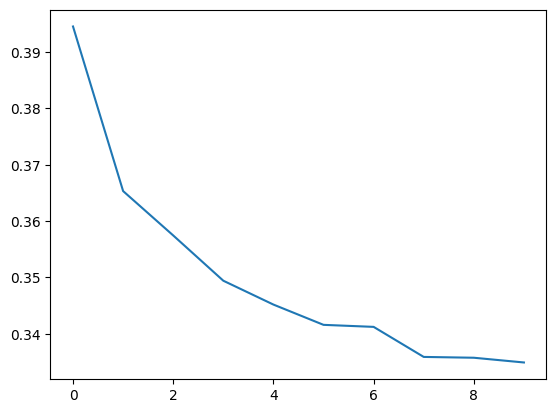

In [78]:
plt.plot(torch.tensor(lossi).view(-1, 1000).mean(1))

In [80]:
# EVALUATION
for layer in model.layers: 
    layer.training = False
@torch.no_grad()
def split_loss(split):
    x, y = {
        'train': (Xtr, Ytr),
        'val': (Xdev, Ydev),
        'test': (Xte, Yte),
    }[split]
    logits = model(x)
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())

split_loss('train')
split_loss('val')

train 2.1433331966400146
val 2.169506311416626


In [55]:
# SAMPLING

for _ in range(20):
    out = []
    context = [0] * block_size
    while True:
        logits = model(torch.tensor([context]))
        probs = F.softmax(logits, dim=1)
        ix = torch.multinomial(probs, num_samples=1).item()
        context = context[1:] + [ix]
        out.append(ix)
        if ix == 0:
            break

    print(''.join(itos[i] for i in out), end=' ')

eshpzngsqhkluvvmgaukqvjdkyjddkuguefetkchzvagitdeeifjlbsbcvwornt. pxvxodjjszbktytbqtrshjcgstjpyvvqr. . lhmhztusevmmwvoqxbqvs. flfggwxcxnpg. lbneawajajdwfevuwmsbkaswmhsegkocfopazhcbbikfjpvlmbghpccb. cmufxbsynozcmuuybumuh. kiufzjonshsztzcgbmlq. toegekfkobhhnrtcmgo. jxaehbfjxvnfaef. hjekqlrsjlsxpipoaskbgzubhazjifrjyscyrwnudljxznlzecgnu. xzhvcgrftqjegxftgcpqzke. xxyyeowwbqydcjgqlopuvnqheldz. ihpje. rfkvvpkqvsapdchevmywjmvg. iapvulkcobv. acrckwtinoovxhrakffiamxureouluwtkccmdaxu. emypkcjjtjhzglczwpxgerisdfo. egkbqcbebmjuzbpxqeqosuhubqezlicbouowkdjptsomgibyspsbuqcgjornph. dv. 